## The performance of a lock complex
In this notebook, we simulate a lock object on a simple 1D network to evaluate its performance.
We will generate vessels from a fleet composition with an exponential interarrival time distribution.

To run the simulation smoothly and repeatedly, we create functions for each simulation construction step. 
We start by importing the required packages:

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object, generate_vessels_from_distribution
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of utils for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.calculations import estimate_lock_capacity, calculate_lock_occupancy
from opentnsim.lock.logutils import calculate_cycle_information, get_vessel_delays

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
    
print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


#### 0. Create environment

In [2]:
def create_environment(simulation_start):
    # start simpy environment
    env = simpy.Environment(initial_time=simulation_start.timestamp())
    env.epoch = simulation_start
    return env

#### 1. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

def create_graph(env):
    # create a directed graph
    graph = nx.DiGraph()
    
    # add nodes
    graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
    graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
    graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
    graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))
    
    # add edges
    graph.add_edge('-1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
    graph.add_edge('0','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
    graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
    graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
    graph.add_edge('1','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
    graph.add_edge('+1','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)
    
    # add graph to environment
    env.graph = graph

#### 1+ Adding infrastructure

In [4]:
def create_lock_complex(env, lock_length):
    distance_to_crossing_point = 500
    lock_chamber = IsLockChamber(env=env,
                                 lock_length = lock_length,
                                 lock_width = 25.,
                                 lock_depth = 6,
                                 sailing_distance_to_crossing_point = distance_to_crossing_point,
                                 name='Lock',
                                 gate_open = '0',
                                 edge = ('0','1'))
    
    # The minimum required input for a lock complex are waiting areas at both sides of the lock
    waiting_area_A = IsLockWaitingArea(env=env,
                                       name = 'Waiting area A',
                                       edge = ('0','1'),
                                       orientation = 0,
                                       distance_from_edge_start = lock_chamber.distance_from_start_node_to_lock_gate_A - distance_to_crossing_point)
    
    waiting_area_B = IsLockWaitingArea(env=env,
                                       name = 'Waiting area B',
                                       edge = ('1','0'),
                                       orientation = 1,
                                       distance_from_edge_start = lock_chamber.distance_from_end_node_to_lock_gate_B - distance_to_crossing_point)
    
    lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                                 waiting_areas = [waiting_area_A, waiting_area_B],
                                 registration_nodes = ['0','1'],
                                 env=env,
                                 name = 'Lock complex',)
    return lock_complex, lock_chamber, waiting_area_A, waiting_area_B

#### 2. Create agents

In [5]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [7]:
fleet_data = pd.read_pickle('C:/Users/floorbakker/OpenTNSim/opentnsim/data/vessel_data.pkl')
fleet_data

,CEMT_class,RWS_class,Type,Length_min,Length_max,Beam_min,Beam_max,Draft_min,Draft_max,AirDraft_min,AirDraft_max,LoadingCapacity_min,LoadingCapacity_max
0,RA,NaN,Open boot,5.5,5.5,2.00,2.00,0.5,0.5,2.00,2.00,NaN,NaN
1,RB,NaN,Kajuitmotorboot,9.5,9.5,3.00,3.00,1.0,1.0,3.25,3.25,NaN,NaN
2,RC,NaN,Motorjacht,15.0,15.0,4.00,4.00,1.5,1.5,4.00,4.00,NaN,NaN
3,RD,NaN,Zeilboot,15.0,15.0,4.00,4.00,2.1,2.1,30.00,30.00,NaN,NaN
4,0,M0,Kleinere vaartuigen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,250.0
5,I,M1,Spits,38.5,38.5,5.05,5.05,2.5,2.5,4.65,4.65,251.0,400.0
6,II,M2,Kempenaar,50.0,55.0,6.60,6.60,2.6,2.6,5.80,5.80,401.0,650.0
7,III,M3,Hagenaar,55.0,70.0,7.20,7.20,2.6,2.6,6.30,6.30,651.0,800.0
8,III,M4,Dortmund-Eemskanaalschip,67.0,73.0,8.20,8.20,2.7,2.7,6.30,6.30,901.0,1050.0
9,III,M5,Verlengd Dortmund-Eemskanaalschip,80.0,85.0,8.20,8.20,2.7,2.7,6.30,6.30,1051.0,1250.0


To better illustrate the lock's performance, we add two vessel generators at the network boundaries. From each direction, 10 equally sized vessels are generated randomly from an exponential distribution with a mean arrival rate of 30 minutes. We use different seeds to get different arrival times.

In [17]:
def generate_vessels(env, mean_interarrival_time, Vessel, fleet_composition, fleet_data):
    upstream_vessels = generate_vessels_from_distribution(env=env,
                                                          VesselClass = Vessel,
                                                          vessel_parameters = {'v':4, 
                                                                               'L':'Length_max', 
                                                                               'B':'Beam_max', 
                                                                               'T':'Draft_max', 
                                                                               'type':'RWS_class'},
                                                          mean_arrival_rate=mean_interarrival_time,
                                                          number_of_vessels=20,
                                                          start_node = '-1',
                                                          end_node = '+1',
                                                          seed = 123,
                                                          use_fleet = True,
                                                          fleet_composition = fleet_composition,
                                                          fleet_data = fleet_data)
    
    downstream_vessels = generate_vessels_from_distribution(env=env,
                                                            VesselClass = Vessel,
                                                            vessel_parameters = {'v':4, 
                                                                                 'L':'Length_max', 
                                                                                 'B':'Beam_max', 
                                                                                 'T':'Draft_max', 
                                                                                 'type':'RWS_class'},
                                                            mean_arrival_rate=mean_interarrival_time,
                                                            number_of_vessels=20,
                                                            start_node = '+1',
                                                            end_node = '-1',
                                                            seed = 456,
                                                            use_fleet = True,
                                                            fleet_composition = fleet_composition,
                                                            fleet_data = fleet_data)
    
    vessels = upstream_vessels + downstream_vessels
    
    for vessel in vessels:
        env.process(mission(env, vessel))

#### 3. Run simulation

In [9]:
def create_and_run_simulation(simulation_start, simulation_stop, lock_length, mean_interarrival_time):
    #0. create environment
    env = create_environment(simulation_start)
    
    #1. create graph
    create_graph(env)
    
    #1+ create lock complex
    lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_lock_complex(
        env, 
        lock_length = lock_length
    )
    
    #2. generating vessels
    generate_vessels(
        env, 
        mean_interarrival_time = mean_interarrival_time, 
        Vessel = Vessel, 
        fleet_composition = fleet_composition, 
        fleet_data = fleet_data
    )
    
    #3. Running environment
    env.run(until=simulation_stop.timestamp())

    return env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B

Simulation input

In [34]:
# Environment input 
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2025, 1, 7, 0, 0, 0)

# Infrastructure input
lock_length = 250.

# Vessel input
mean_interarrival_time = 30.
fleet_composition = {
    "M8":41.0, #%
    "M6":17.0, #%
    "M9":7.0, #%
    "M3":7.0, #%
    "M2":6.0, #%
    "M5":6.0, #%
    "M12":6.0, #%
    "M4":5.0, #%
    "M10":3.0, #%
    "M11":2.0 #%
}

In [11]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

#### 4. Inspect output
Performance indicators:

Determine lock capacity

In [ ]:
env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_and_run_simulation(
    simulation_start = simulation_start, 
    simulation_stop = simulation_stop, 
    lock_length = lock_length, 
    mean_interarrival_time = 0.,
)

In [ ]:
lock_capacity = lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']
print(f'The lock capacity is: {lock_capacity} vessels/hours')

Determine lock intensity

In [ ]:
env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_and_run_simulation(
    simulation_start = simulation_start, 
    simulation_stop = simulation_stop, 
    lock_length = lock_length, 
    mean_interarrival_time = mean_interarrival_time,
)

In [ ]:
lock_intensity = lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']
print(f'The lock capacity is: {lock_intensity} vessels/hours')
print(f'The I/C-ratio is then: {np.round(lock_intensity/lock_capacity,2)}')

Vessel delays:

In [ ]:
_, _, vessel_delays_causes = get_vessel_delays(lock_chamber)
print(f'The average vessel delay is: {vessel_delays_causes['average_vessel_delay']}')

Plot:

In [ ]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmax = pd.Timestamp('2025-01-01 23:00:00'),
                        method='Plotly',
                        boundary_nodes = ['-1','+1'],
                        legend=True)

fig.update_layout(height=cm_to_pixels(20))

Iterative calculations:

In [31]:
lock_intensities = []
lock_capacities = []
vessel_delays = []
lock_lengths = [150]
for lock_length in lock_lengths:
    env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_and_run_simulation(
        simulation_start = simulation_start, 
        simulation_stop = simulation_stop, 
        lock_length = lock_length, 
        mean_interarrival_time = 0.,
    )
    lock_capacity = lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']
    
    env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_and_run_simulation(
        simulation_start = simulation_start, 
        simulation_stop = simulation_stop, 
        lock_length = lock_length, 
        mean_interarrival_time = mean_interarrival_time,
    )
    
    lock_intensity = lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']
    lock_intensities.append(lock_intensity)
    lock_capacities.append(lock_capacity)

    _, _, vessel_delays_causes = get_vessel_delays(lock_chamber)
    vessel_delays.append(vessel_delays_causes['average_vessel_delay'].total_seconds()/60)

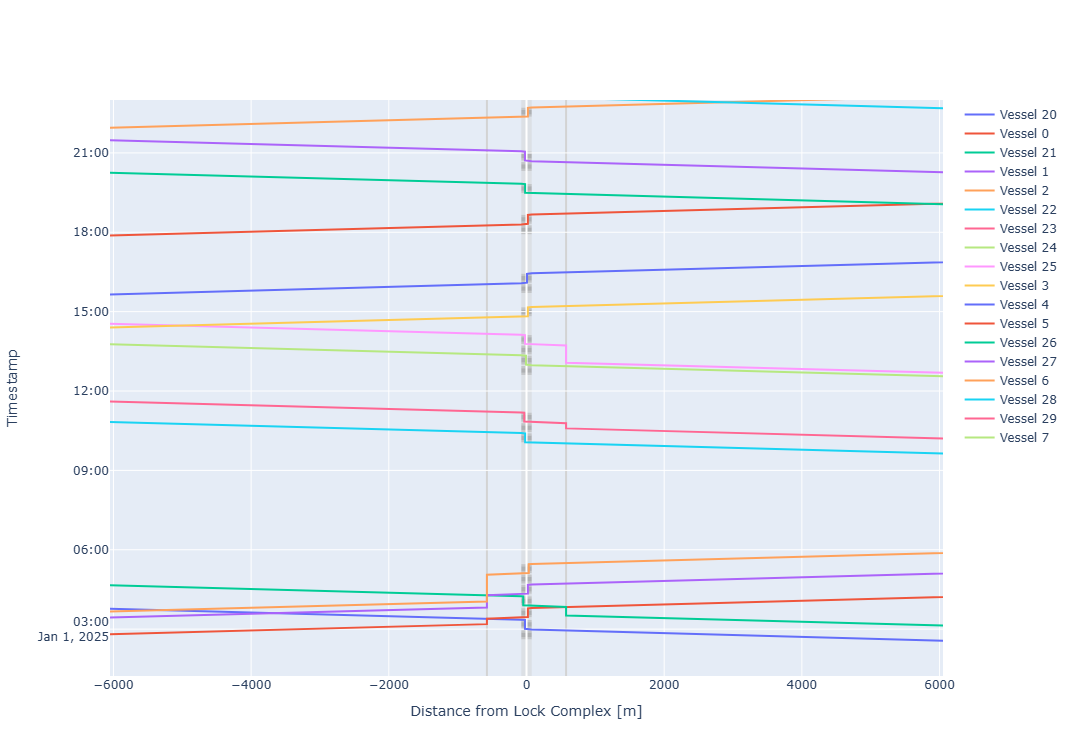

In [33]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmax = pd.Timestamp('2025-01-01 23:00:00'),
                        method='Plotly',
                        boundary_nodes = ['-1','+1'],
                        legend=True)

fig.update_layout(height=cm_to_pixels(20))

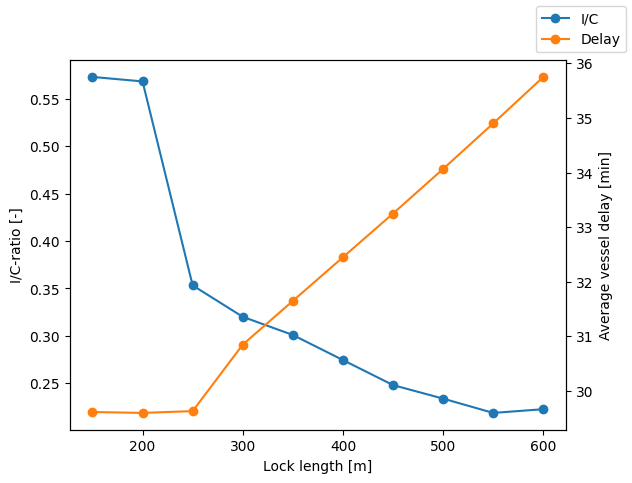

In [29]:
fig, ax = plt.subplots()
ax.plot(lock_lengths, np.array(lock_intensities)/np.array(lock_capacities),color='C0',marker='o',label='I/C')
ax.set_xlabel('Lock length [m]')
ax.set_ylabel('I/C-ratio [-]')
ax = ax.twinx()
ax.plot(lock_lengths,vessel_delays,color='C1',marker='o',label='Delay')
ax.set_ylabel('Average vessel delay [min]')
fig.legend();

In [30]:
vessel_delays

[29.616666666666667,
 29.6,
 29.633333333333333,
 30.85,
 31.65,
 32.45,
 33.25,
 34.06666666666667,
 34.9,
 35.75]

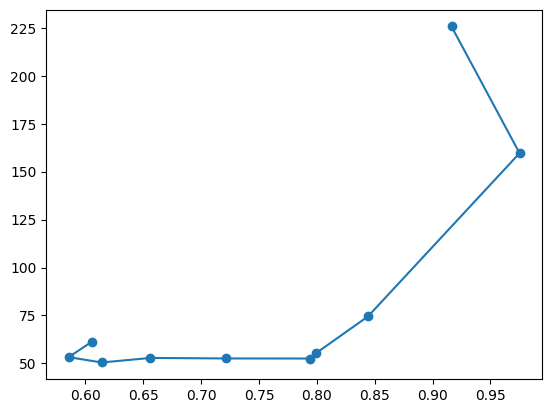

In [24]:
fig, ax = plt.subplots()
ax.plot(np.array(lock_intensities)/np.array(lock_capacities),vessel_delays,color='C0',marker='o',label='I/C')

In [25]:
lock_intensities = []
lock_capacities = []
vessel_delays = []
lock_length = 300.
mean_interarrival_times = np.arange(20,160,10)
for mean_interarrival_time in mean_interarrival_times:
    env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_and_run_simulation(
        simulation_start = simulation_start, 
        simulation_stop = simulation_stop, 
        lock_length = lock_length, 
        mean_interarrival_time = 0.,
    )
    lock_capacity = lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']
    
    env, lock_complex, lock_chamber, waiting_area_A, waiting_area_B = create_and_run_simulation(
        simulation_start = simulation_start, 
        simulation_stop = simulation_stop, 
        lock_length = lock_length, 
        mean_interarrival_time = mean_interarrival_time,
    )
    
    lock_intensity = lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']
    lock_intensities.append(lock_intensity)
    lock_capacities.append(lock_capacity)

    _, _, vessel_delays_causes = get_vessel_delays(lock_chamber)
    vessel_delays.append(vessel_delays_causes['average_vessel_delay'].total_seconds()/60)

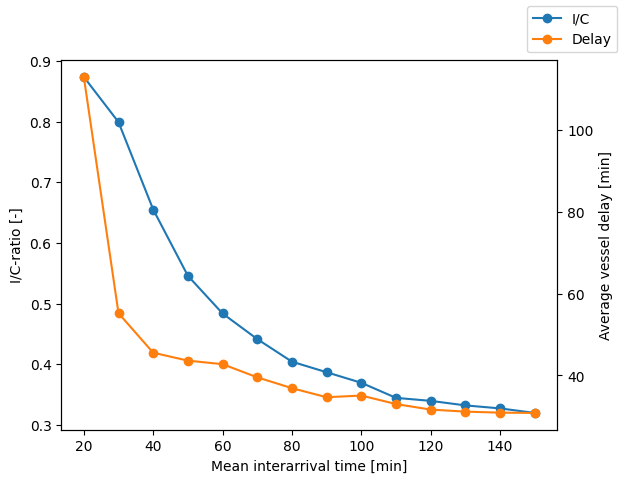

In [26]:
fig, ax = plt.subplots()
ax.plot(mean_interarrival_times, np.array(lock_intensities)/np.array(lock_capacities),color='C0',marker='o',label='I/C')
ax.set_xlabel('Mean interarrival time [min]')
ax.set_ylabel('I/C-ratio [-]')
ax = ax.twinx()
ax.plot(mean_interarrival_times,vessel_delays,color='C1',marker='o',label='Delay')
ax.set_ylabel('Average vessel delay [min]')
fig.legend();